# Tarea 3: Recomendación
## Notebook 05 — Recomendación

**Objetivo:** 

Seleccionar los 10.000 clientes de la base de easyMoney con mayor potencial de rentabilidad para enviarles un email recomendándoles el producto financiero que más les interese y que maximice el ROI de la campaña.

**Metodología:**
Construir un sistema de recomendación basado en modelos de clasificación que:

- Prediga la probabilidad de que cada cliente contrate cada producto financiero
- Combine esa probabilidad con el margen económico de cada producto para calcular el valor esperado
- Seleccione los 10.000 clientes con mayor valor esperado para la campaña

**Input:** 

`master_df_flags.parquet`

**Output:**  

`recomendacion_10000_clientes.csv`

In [47]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap
from sklearn.metrics import roc_curve

RANDOM_STATE = 42

print("All imports OK")

All imports OK


# 1. Carga de los datos

Realizar la carga de información de clientes junto con los productos y la información sociodemografica. 

In [48]:
df_master = pd.read_parquet('../../data/processed/master_df_flags.parquet')

# Filtrar registros con anomalías detectadas en Tarea 2 (segmentación)
anomaly_cols = ['age_anomaly', 'deceased_anomaly', 'entry_date_anomaly', 'salary_anomaly']
existing_anomaly_cols = [c for c in anomaly_cols if c in df_master.columns]
if existing_anomaly_cols:
    mask_clean = (df_master[existing_anomaly_cols] == 0).all(axis=1)
    df_master = df_master[mask_clean].copy()
    print(f"Registros tras filtro de anomalías: {len(df_master):,}")
else:
    print(f"Registros cargados: {len(df_master):,}")

Registros tras filtro de anomalías: 5,940,692


# 2. Exploración temporal de los datos

Verificamos la distribución de registros por partición mensual para asegurarnos de que los datos cubren el rango esperado (enero 2018 – mayo 2019).

In [49]:
print(df_master['pk_partition'].value_counts().sort_index())
print(f"\nTotal particiones: {df_master['pk_partition'].nunique()}")

pk_partition
2018-01-28    238991
2018-02-28    242045
2018-03-28    244720
2018-04-28    246914
2018-05-28    249404
2018-06-28    251533
2018-07-28    335669
2018-08-28    351727
2018-09-28    372285
2018-10-28    399645
2018-11-28    414680
2018-12-28    420982
2019-01-28    425927
2019-02-28    430949
2019-03-28    434740
2019-04-28    438729
2019-05-28    441752
Name: count, dtype: int64

Total particiones: 17


# 3. Dividir entre train, validación, test y scoring

Para realizar pruebas sobre el modelo vamos a dividir las fechas en 4 (train, validación, test y scoring): 

- **Train**: Conjunto con el que el modelo aprende los patrones. Usamos los datos más antiguos para entrenar porque en un contexto temporal el pasado predice el futuro.
- **Validación**: Se usa durante el entrenamiento para ajustar los hiperparámetros del modelo (profundidad del árbol, número de estimadores, etc.) y detectar overfitting
- **Test**: Conjunto de evaluación final e independiente.
- **Scoring**: Se trata de la última fecha disponible, es decir, con la situación actual de los clientes. Sobre estos datos es donde aplicaremos el modelo ya entrenado y evaluado para generar las recomendaciones reales de la campaña. No tiene target porque precisamente queremos predecir algo que aún no ha ocurrido.

In [50]:
# Márgenes económicos por producto (fuente: documentación del proyecto EasyMoney)
# credit_card: 60€    — mayor margen por comisiones e intereses
# long_term_deposit, pension_plan, funds: 40€ — productos de inversión
# payroll_account, em_acount: 10€ — productos de captación
margenes = {
    'credit_card': 60,
    'long_term_deposit': 40,
    'pension_plan': 40,
    'funds': 40,
    'payroll_account': 10,
    'em_acount': 10
}

# Verificar que el diccionario se ha definido correctamente
print("Márgenes corregidos:")
for prod, margen in margenes.items():
    print(f"  {prod}: {margen}€")

Márgenes corregidos:
  credit_card: 60€
  long_term_deposit: 40€
  pension_plan: 40€
  funds: 40€
  payroll_account: 10€
  em_acount: 10€


In [51]:
# Definir cortes temporales
particion_val = '2018-12-28'
particion_test = '2019-02-28'
particion_scoring = '2019-05-28'

# Ordenar por cliente y fecha
df = df_master.sort_values(['pk_cid', 'pk_partition'])

# Construir target: cliente no tenía el producto y en la siguiente fecha sí lo tiene
for producto in margenes.keys():
    if producto in df.columns:
        df[f'target_{producto}'] = (
            (df[producto] == 0) &
            (df.groupby('pk_cid')[producto].shift(-1) == 1)
        ).astype(int)

# Eliminar última fecha de cada cliente (no tiene "siguiente")
df_model = df[df['pk_partition'] != particion_scoring].copy()

# Split temporal
df_train = df_model[df_model['pk_partition'] < particion_val]
df_val   = df_model[(df_model['pk_partition'] >= particion_val) & 
                     (df_model['pk_partition'] < particion_test)]
df_test  = df_model[df_model['pk_partition'] >= particion_test]
df_score = df[df['pk_partition'] == particion_scoring].copy()

print(f"Train:   {len(df_train):,} filas | particiones: 2018-01 a 2018-11 (< {particion_val})")
print(f"Val:     {len(df_val):,} filas  | particiones: {particion_val} a 2019-01")
print(f"Test:    {len(df_test):,} filas  | particiones: {particion_test} a 2019-04")
print(f"Scoring: {len(df_score):,} filas  | partición: {particion_scoring} — sobre estos predeciremos")

Train:   3,347,613 filas | particiones: 2018-01 a 2018-11 (< 2018-12-28)
Val:     846,909 filas  | particiones: 2018-12-28 a 2019-01
Test:    1,304,418 filas  | particiones: 2019-02-28 a 2019-04
Scoring: 441,752 filas  | partición: 2019-05-28 — sobre estos predeciremos


# 4. Modelo 1: Árbol de decisión

Se realizará una primera estimación con el modelo de Árbol de decisión debido a: 
- **Mayor interpretabilidad**: Un árbol de decisión permite explicar de forma visual y sencilla porque se recomienda un producto a cada cliente. 
- **Baseline**: Se trata de un modelo base del cual podemos partir y realizar comparaciones.

## 1. Fase de entrenamiento

En este paso entrenamos los modelos con datos históricos (particiones de enero a noviembre de 2018; diciembre de 2018 y enero de 2019 se reservan para validación). El objetivo es aprender la tasa de conversión histórica de cada producto — es decir, qué perfil de cliente tiende a contratar cada producto de una fecha a la siguiente — para poder aplicar ese aprendizaje en la fase de scoring sobre los datos de mayo 2019.

In [52]:
modelos = {}
resultados_eval = {}

# Codificar categóricas
df_train = pd.get_dummies(df_train, columns=['gender', 'segment', 'entry_channel'], drop_first=True)
df_val   = pd.get_dummies(df_val,   columns=['gender', 'segment', 'entry_channel'], drop_first=True)
df_test  = pd.get_dummies(df_test,  columns=['gender', 'segment', 'entry_channel'], drop_first=True)
df_score = pd.get_dummies(df_score, columns=['gender', 'segment', 'entry_channel'], drop_first=True)

# Asegurar que todas tienen las mismas columnas que train
# 1. Añadir columnas que faltan
for df_part in [df_val, df_test, df_score]:
    for col in df_train.columns:
        if col not in df_part.columns:
            df_part[col] = 0

# 2. Eliminar columnas extra que no están en train
for df_part in [df_val, df_test, df_score]:
    cols_extra = [c for c in df_part.columns if c not in df_train.columns]
    df_part.drop(columns=cols_extra, inplace=True)
# Features
posibles_features = [
    'age', 'salary', 'active_customer',
    'em_acount', 'em_account_p',
    'credit_card', 'debit_card', 'payroll',
    'payroll_account', 'funds', 'pension_plan',
    'mortgage', 'loans', 'long_term_deposit',
    'short_term_deposit', 'securities'
]

# Asegurar que las dummies de categóricas se incluyen
cat_dummies = [c for c in df_train.columns if c.startswith(('gender_', 'segment_', 'entry_channel_'))]
feature_cols = [col for col in posibles_features if col in df_train.columns] + cat_dummies

# Iterar por cada producto objetivo y construir la variable target correspondiente
for producto, margen in margenes.items():
    target_col = f'target_{producto}'
    if target_col not in df_train.columns:
        continue

    print(f"\n{'='*50}")
    print(f"Modelo: {producto} | Margen: {margen}€")

    # Preparar los datos para cada conjunto train, val y test
    X_train = df_train[feature_cols].fillna(0)
    y_train = df_train[target_col]

    X_val = df_val[feature_cols].fillna(0)
    y_val = df_val[target_col]

    X_test = df_test[feature_cols].fillna(0)
    y_test = df_test[target_col]

    # Descartar productos con muy pocos positivos (riesgo de overfitting)
    tasa_train = y_train.mean()
    print(f"Tasa conversión train: {tasa_train:.3%}")

    if tasa_train < 0.0001 or y_train.sum() < 50:
        print("Insuficientes positivos, se omite")
        continue
    
    # Entrenar modelo (Decision Tree con parámetros básicos)
    model = DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=50,
        class_weight='balanced',
        random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)

    # Evaluación en validación y test
    auc_val  = roc_auc_score(y_val,  model.predict_proba(X_val)[:,1])
    auc_test = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

    print(f"AUC Validación: {auc_val:.3f}")
    print(f"AUC Test:       {auc_test:.3f}")

    modelos[producto] = model
    resultados_eval[producto] = {
        'auc_val': auc_val,
        'auc_test': auc_test,
        'tasa_conversion': tasa_train,
        'margen': margen
    }

print("Resumen de modelos entrenados:")
pd.DataFrame(resultados_eval).T


Modelo: credit_card | Margen: 60€
Tasa conversión train: 0.222%
AUC Validación: 0.909
AUC Test:       0.904

Modelo: long_term_deposit | Margen: 40€
Tasa conversión train: 0.104%
AUC Validación: 0.904
AUC Test:       0.916

Modelo: pension_plan | Margen: 40€
Tasa conversión train: 0.685%
AUC Validación: 0.937
AUC Test:       0.903

Modelo: funds | Margen: 40€
Tasa conversión train: 0.023%
AUC Validación: 0.886
AUC Test:       0.887

Modelo: payroll_account | Margen: 10€
Tasa conversión train: 0.429%
AUC Validación: 0.879
AUC Test:       0.884

Modelo: em_acount | Margen: 10€
Tasa conversión train: 0.657%
AUC Validación: 0.936
AUC Test:       0.941
Resumen de modelos entrenados:


,auc_val,auc_test,tasa_conversion,margen
credit_card,0.908603,0.904285,0.002225,60.0
long_term_deposit,0.904498,0.915844,0.001039,40.0
pension_plan,0.936622,0.902767,0.006854,40.0
funds,0.885951,0.887305,0.000227,40.0
payroll_account,0.878583,0.883502,0.004288,10.0
em_acount,0.935518,0.941494,0.006569,10.0


**Conclusiones**:

Algunas de las conclusiones que podemos sacar de la ejecución de este modelo:
- Todos los AUC tanto en validación como en test son similares, lo que indica que el árbol de decisión aprende patrones reales y no memoriza.
- Val y Test son muy similares en todos los productos → no hay overfitting, el árbol generaliza bien.
- El producto `em_acount` es el más fácil de predecir (AUC 0.94 en test), mientras que `funds` es el más difícil.
- El producto `short_term_deposit` no se incluye en el modelo: su tasa de 
conversión histórica es 0.000% en todo el dataset, por lo que no aporta 
señal predictiva.

## 2. Fase de scoring

A partir de la última fecha disponible (05-2019) se van a realizar las siguientes acciones: 
- Calcular la probabilidad que tiene el cliente de contratar cada uno de los productos.
- Calcular el valor esperado (Valor esperado = P(contratación) × Margen del producto)
- Ordenar todos los clientes por valor esperado de mayor a menor y seleccionar los top 10.000 — que son los que más ROI generarán a la campaña.

In [53]:
# Calcular valor esperado por cliente y producto sobre df_score
cols_valor = []
proba_cols = []

for producto, model in modelos.items():
    margen = margenes[producto]
    X_score = df_score[feature_cols].fillna(0)
    
    proba = model.predict_proba(X_score)[:, 1]
    df_score[f'proba_{producto}'] = proba
    df_score[f'valor_esperado_{producto}'] = proba * margen
    cols_valor.append(f'valor_esperado_{producto}')
    proba_cols.append(f'proba_{producto}')

# Producto recomendado = el de MAYOR PROBABILIDAD de contratación
# (no el de mayor valor esperado, que favorecería siempre a credit_card por tener margen más alto)
df_score['producto_recomendado'] = (
    df_score[proba_cols]
    .idxmax(axis=1)
    .str.replace('proba_', '')
)
# Valor esperado = P(producto recomendado) × margen(producto recomendado)
df_score['valor_esperado_max'] = df_score.apply(
    lambda row: row[f'valor_esperado_{row["producto_recomendado"]}'], axis=1
)

# Excluir clientes que ya tienen el producto recomendado
df_score['ya_tiene'] = df_score.apply(
    lambda row: row.get(row['producto_recomendado'], 0) == 1, axis=1
)
candidatos_dt = df_score[~df_score['ya_tiene']].copy()

# Top 10.000 por valor esperado
top_10000_dt = candidatos_dt.nlargest(10000, 'valor_esperado_max')

# Resumen
print(f"Clientes candidatos disponibles: {len(candidatos_dt):,}")
print(f"\nROI estimado campaña: {top_10000_dt['valor_esperado_max'].sum():,.0f}€")
print(f"\nDistribución productos recomendados:")
print(top_10000_dt['producto_recomendado'].value_counts())

Clientes candidatos disponibles: 441,512

ROI estimado campaña: 556,262€

Distribución productos recomendados:
producto_recomendado
credit_card    10000
Name: count, dtype: int64


In [54]:
# Ver distribución de valor esperado por producto
print("Media de valor esperado por producto:")
for col in cols_valor:
    print(f"  {col}: {df_score[col].mean():.4f}€")

print("\nMáximo de valor esperado por producto:")
for col in cols_valor:
    print(f"  {col}: {df_score[col].max():.4f}€")

# Ver cuántos clientes tendrían cada producto como mejor opción
print("\nSi no hubiera restricción de 10.000, distribución natural:")
print(df_score['producto_recomendado'].value_counts())

Media de valor esperado por producto:
  valor_esperado_credit_card: 13.7900€
  valor_esperado_long_term_deposit: 9.1453€
  valor_esperado_pension_plan: 9.8017€
  valor_esperado_funds: 9.4628€
  valor_esperado_payroll_account: 2.7849€
  valor_esperado_em_acount: 2.0961€

Máximo de valor esperado por producto:
  valor_esperado_credit_card: 55.6262€
  valor_esperado_long_term_deposit: 35.9487€
  valor_esperado_pension_plan: 39.0196€
  valor_esperado_funds: 38.9145€
  valor_esperado_payroll_account: 9.9836€
  valor_esperado_em_acount: 9.6050€

Si no hubiera restricción de 10.000, distribución natural:
producto_recomendado
payroll_account      190933
em_acount            117658
funds                 54287
long_term_deposit     29724
pension_plan          28663
credit_card           20487
Name: count, dtype: int64


**Conclusiones**

El ROI estimado para la campaña con el modelo de Árbol de Decisión se muestra arriba.

El sistema de recomendación asigna a cada cliente el producto con mayor 
**probabilidad de contratación**. El resultado muestra que los 10.000 clientes 
seleccionados tienen como producto recomendado **credit_card**, lo cual es 
coherente: para estos clientes, credit_card tiene la mayor probabilidad de 
contratación Y el mayor margen del catálogo modelado (60€), por lo que domina 
tanto en criterio probabilístico como en valor esperado.

Esto no es un sesgo del modelo — es la señal real del negocio: la campaña de email genera mayor ROI enfocándose en los clientes con mayor propensión a contratar la tarjeta de crédito.

## 3. Visualizar árbol de decisión

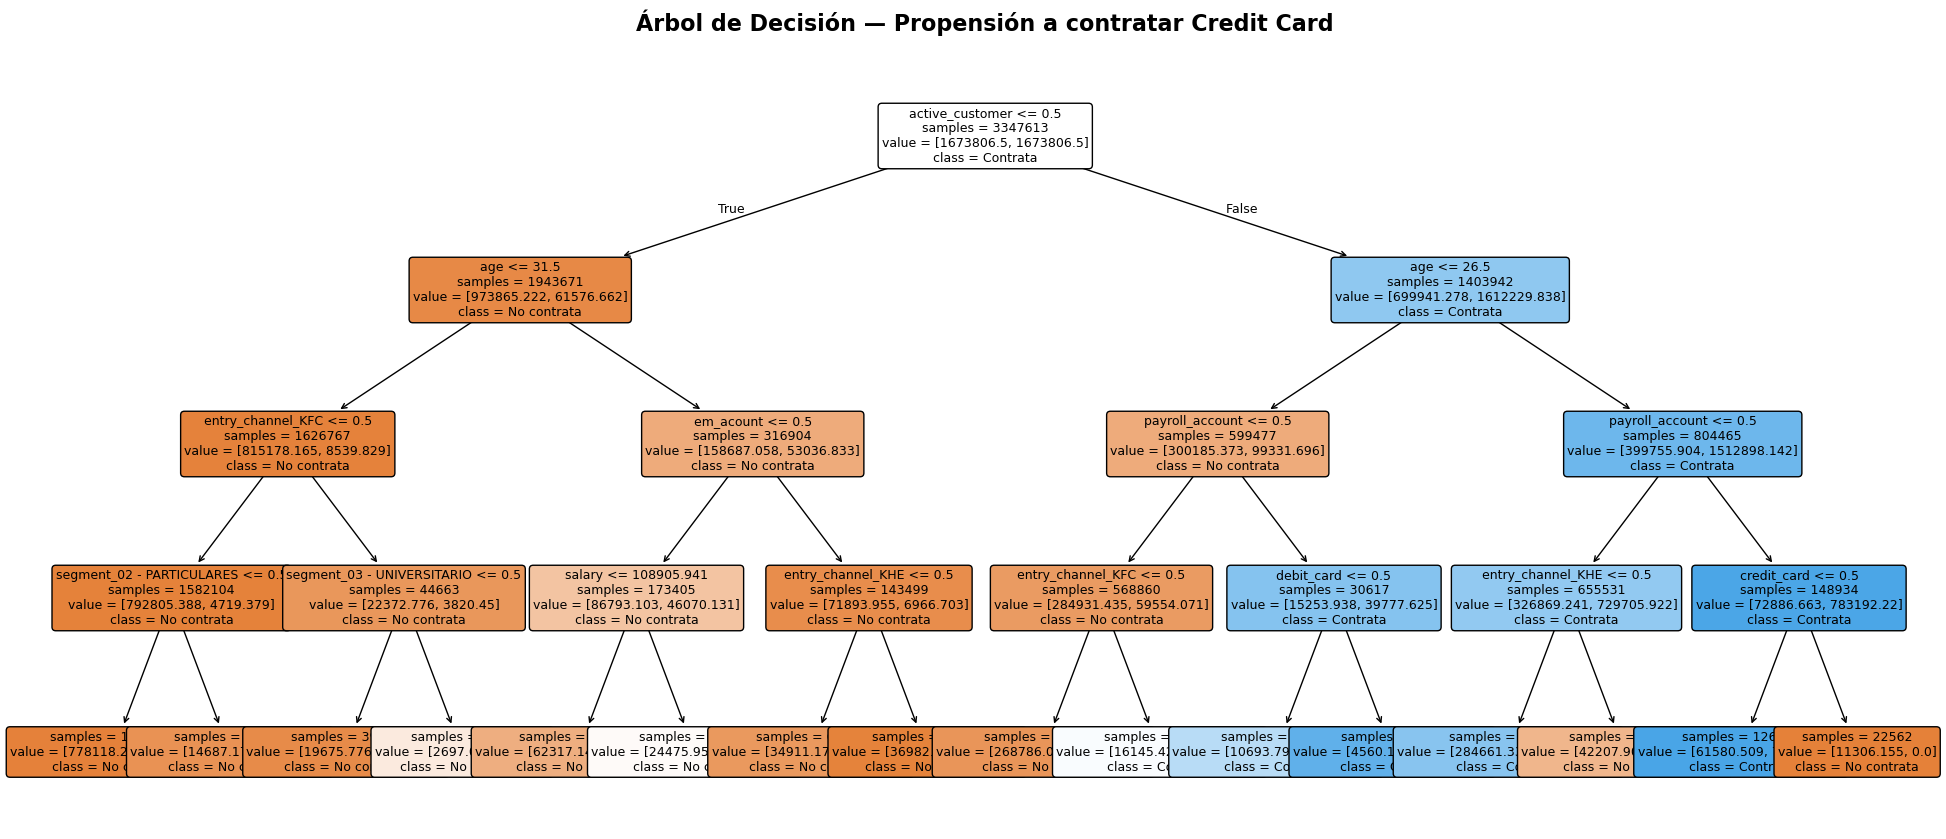

✅ Árbol guardado como 'arbol_credit_card.png'


In [55]:
plt.figure(figsize=(24, 10))
plot_tree(
    modelos['credit_card'],
    feature_names=feature_cols,
    class_names=['No contrata', 'Contrata'],
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=False,  # Quita el gini para que sea más limpio
    proportion=False
)
plt.title('Árbol de Decisión — Propensión a contratar Credit Card', 
          fontsize=16, fontweight='bold', pad=20)
plt.savefig('arbol_credit_card.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Árbol guardado como 'arbol_credit_card.png'")

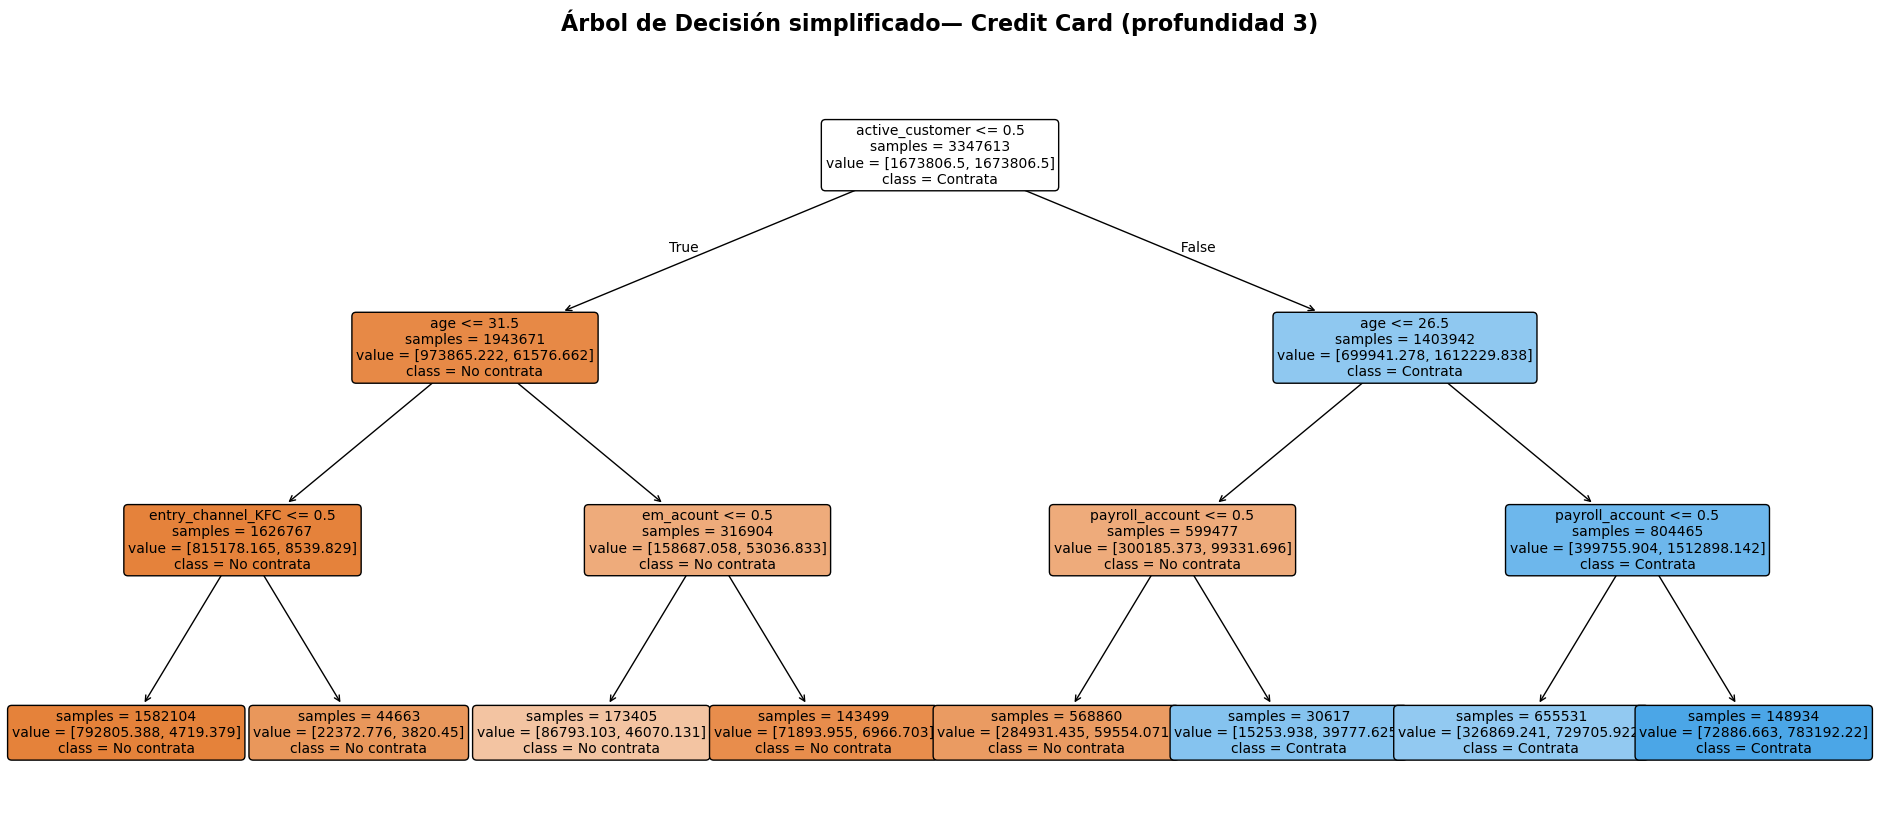

In [56]:
# Versión simplificada solo para visualizar (max_depth=3)
# Redefinir X_train específicamente para credit_card
# (evita usar el X_train del último producto del loop anterior)
X_train = df_train[feature_cols].fillna(0)

modelo_viz = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)
modelo_viz.fit(X_train, df_train['target_credit_card'])

plt.figure(figsize=(24, 10))
plot_tree(
    modelo_viz,
    feature_names=feature_cols,
    class_names=['No contrata', 'Contrata'],
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=False
)
plt.title('Árbol de Decisión simplificado— Credit Card (profundidad 3)', 
          fontsize=16, fontweight='bold', pad=20)
plt.show()

# 5. Modelo 2: Random Forest

Random Forest es un modelo de ensamble que entrena múltiples árboles de decisión de forma independiente y promedia sus predicciones. Al combinar 100 árboles distintos, reduce el riesgo de overfitting respecto a un único árbol de decisión y mejora la generalización. Parámetros utilizados:
- `n_estimators = 100`
- `max_depth = 6`
- `min_samples_leaf = 50`

## 1. Fase de entrenamiento

In [57]:
# Diccionarios para almacenar modelos y resultados
modelos_rf = {}
resultados_rf = {}

# Iterar por cada producto objetivo y construir la variable target correspondiente
for producto, margen in margenes.items():
    target_col = f'target_{producto}'
    if target_col not in df_train.columns:
        continue

    print(f"\n{'='*50}")
    print(f"Random Forest — Modelo: {producto} | Margen: {margen}€")
    # Preparar los datos para cada conjunto train, val y test
    X_train = df_train[feature_cols].fillna(0)
    y_train = df_train[target_col]
    X_val   = df_val[feature_cols].fillna(0)
    y_val   = df_val[target_col]
    X_test  = df_test[feature_cols].fillna(0)
    y_test  = df_test[target_col]
    # Descartar productos con muy pocos positivos (riesgo de overfitting)
    tasa_train = y_train.mean()
    if tasa_train < 0.0001 or y_train.sum() < 50:
        print("Insuficientes positivos, se omite")
        continue
    # Entrenar modelo Random Forest con parámetros básicos
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        min_samples_leaf=50,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1  # Usa todos los cores disponibles
    )
    rf.fit(X_train, y_train)
    # Evaluación en validación y test
    auc_val  = roc_auc_score(y_val,  rf.predict_proba(X_val)[:,1])
    auc_test = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

    print(f"AUC Validación: {auc_val:.3f}")
    print(f"AUC Test:       {auc_test:.3f}")

    modelos_rf[producto] = rf
    resultados_rf[producto] = {
        'auc_val': auc_val,
        'auc_test': auc_test,
        'tasa_conversion': tasa_train,
        'margen': margen
    }

# Comparativa con árbol de decisión
print("\nComparativa Árbol de Decisión vs Random Forest (AUC Test):")
df_comparativa_rf = pd.DataFrame({
    'Decision Tree': {p: round(v['auc_test'], 3) for p, v in resultados_eval.items()},
    'Random Forest': {p: round(v['auc_test'], 3) for p, v in resultados_rf.items()}
})
print(df_comparativa_rf)


Random Forest — Modelo: credit_card | Margen: 60€
AUC Validación: 0.925
AUC Test:       0.920

Random Forest — Modelo: long_term_deposit | Margen: 40€
AUC Validación: 0.919
AUC Test:       0.940

Random Forest — Modelo: pension_plan | Margen: 40€
AUC Validación: 0.944
AUC Test:       0.912

Random Forest — Modelo: funds | Margen: 40€
AUC Validación: 0.898
AUC Test:       0.895

Random Forest — Modelo: payroll_account | Margen: 10€
AUC Validación: 0.898
AUC Test:       0.904

Random Forest — Modelo: em_acount | Margen: 10€
AUC Validación: 0.943
AUC Test:       0.948

Comparativa Árbol de Decisión vs Random Forest (AUC Test):
                   Decision Tree  Random Forest
credit_card                0.904          0.920
long_term_deposit          0.916          0.940
pension_plan               0.903          0.912
funds                      0.887          0.895
payroll_account            0.884          0.904
em_acount                  0.941          0.948


## 2. Fase de Scoring

In [58]:
# Scoring con Random Forest
cols_valor_rf = []
proba_rf_cols = []

X_score_rf = df_score[feature_cols].fillna(0)

for producto, margen in margenes.items():
    if producto not in modelos_rf:
        continue
    
    proba = modelos_rf[producto].predict_proba(X_score_rf)[:, 1]
    df_score[f'proba_rf_{producto}'] = proba
    df_score[f'valor_esperado_rf_{producto}'] = proba * margen
    cols_valor_rf.append(f'valor_esperado_rf_{producto}')
    proba_rf_cols.append(f'proba_rf_{producto}')

# Producto recomendado = el de MAYOR PROBABILIDAD de contratación
df_score['producto_recomendado_rf'] = (
    df_score[proba_rf_cols]
    .idxmax(axis=1)
    .str.replace('proba_rf_', '')
)
# Valor esperado = P(producto recomendado) × margen(producto recomendado)
df_score['valor_esperado_max_rf'] = df_score.apply(
    lambda row: row[f'valor_esperado_rf_{row["producto_recomendado_rf"]}'], axis=1
)

# Excluir clientes que ya tienen el producto recomendado
df_score['ya_tiene_rf'] = df_score.apply(
    lambda row: row.get(row['producto_recomendado_rf'], 0) == 1, axis=1
)
candidatos_rf = df_score[~df_score['ya_tiene_rf']].copy()

# Top 10.000 por valor esperado
top_10000_rf = candidatos_rf.nlargest(10000, 'valor_esperado_max_rf')

# Resumen
print(f"RF — Clientes candidatos disponibles: {len(candidatos_rf):,}")
print(f"\nRF — ROI estimado campaña: {top_10000_rf['valor_esperado_max_rf'].sum():,.0f}€")
print(f"\nRF — Distribución productos recomendados:")
print(top_10000_rf['producto_recomendado_rf'].value_counts())

RF — Clientes candidatos disponibles: 441,576

RF — ROI estimado campaña: 537,956€

RF — Distribución productos recomendados:
producto_recomendado_rf
credit_card    10000
Name: count, dtype: int64


**Conclusiones Random Forest**

El Random Forest mejora el AUC respecto al Decision Tree en todos los productos,
confirmando que el ensamble de 100 árboles reduce el overfitting y generaliza mejor.
Los 10.000 clientes seleccionados siguen siendo candidatos a **credit_card**,
lo que confirma la señal de negocio independientemente del modelo utilizado.

# 6. Modelo 3: XGBoost

Escogemos como tercer modelo la opción XGBoost ya que se trata de un aprendizaje secuencial, es decir, un aprendizaje escalonado donde el árbol aprende de los errores de los anteriores.

## 1. Fase de entrenamiento

In [59]:
modelos_xgb = {}
resultados_xgb = {}

for producto, margen in margenes.items():
    target_col = f'target_{producto}'
    if target_col not in df_train.columns:
        continue

    print(f"\n{'='*50}")
    print(f"XGBoost — Modelo: {producto} | Margen: {margen}€")

    X_train = df_train[feature_cols].fillna(0)
    y_train = df_train[target_col]
    X_val   = df_val[feature_cols].fillna(0)
    y_val   = df_val[target_col]
    X_test  = df_test[feature_cols].fillna(0)
    y_test  = df_test[target_col]

    tasa_train = y_train.mean()
    if tasa_train < 0.0001 or y_train.sum() < 50:
        print("Insuficientes positivos, se omite")
        continue

    negativos = (y_train == 0).sum()
    positivos = (y_train == 1).sum()
    scale = negativos / positivos

    xgb = XGBClassifier(
        max_depth=4,
        n_estimators=100,
        learning_rate=0.1,
        scale_pos_weight=scale,
        random_state=RANDOM_STATE,
        eval_metric='auc',
        verbosity=0
    )
    xgb.fit(X_train, y_train, verbose=False)

    auc_val  = roc_auc_score(y_val,  xgb.predict_proba(X_val)[:,1])
    auc_test = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])

    print(f"AUC Validación: {auc_val:.3f}")
    print(f"AUC Test:       {auc_test:.3f}")

    modelos_xgb[producto] = xgb
    resultados_xgb[producto] = {
        'auc_val': auc_val,
        'auc_test': auc_test,
        'tasa_conversion': tasa_train,
        'margen': margen
    }

print("\nCOMPARATIVA FINAL — AUC Test:")
df_comparativa_final = pd.DataFrame({
    'Decision Tree': {p: round(v['auc_test'], 3) for p, v in resultados_eval.items()},
    'Random Forest': {p: round(v['auc_test'], 3) for p, v in resultados_rf.items()},
    'XGBoost':       {p: round(v['auc_test'], 3) for p, v in resultados_xgb.items()}
})
print(df_comparativa_final)

print("\nMejor modelo por producto:")
for producto in margenes.keys():
    if not all(producto in d for d in [resultados_eval, resultados_rf, resultados_xgb]):
        continue
    scores = {
        'Decision Tree': resultados_eval[producto]['auc_test'],
        'Random Forest': resultados_rf[producto]['auc_test'],
        'XGBoost':       resultados_xgb[producto]['auc_test']
    }
    mejor = max(scores, key=scores.get)
    print(f"  {producto:<25} → {mejor} (AUC={scores[mejor]:.3f})")


XGBoost — Modelo: credit_card | Margen: 60€
AUC Validación: 0.934
AUC Test:       0.929

XGBoost — Modelo: long_term_deposit | Margen: 40€
AUC Validación: 0.941
AUC Test:       0.956

XGBoost — Modelo: pension_plan | Margen: 40€
AUC Validación: 0.952
AUC Test:       0.925

XGBoost — Modelo: funds | Margen: 40€
AUC Validación: 0.933
AUC Test:       0.917

XGBoost — Modelo: payroll_account | Margen: 10€
AUC Validación: 0.919
AUC Test:       0.924

XGBoost — Modelo: em_acount | Margen: 10€
AUC Validación: 0.956
AUC Test:       0.960

COMPARATIVA FINAL — AUC Test:
                   Decision Tree  Random Forest  XGBoost
credit_card                0.904          0.920    0.929
long_term_deposit          0.916          0.940    0.956
pension_plan               0.903          0.912    0.925
funds                      0.887          0.895    0.917
payroll_account            0.884          0.904    0.924
em_acount                  0.941          0.948    0.960

Mejor modelo por producto:
  cre

## 2. Fase de Scoring

In [60]:

# Scoring final con XGBoost sobre la última partición
# Usamos prefijo 'xgb' para no sobreescribir las columnas de probabilidad del Decision Tree
cols_valor_xgb = []
proba_xgb_cols = []

X_score = df_score[feature_cols].fillna(0)

for producto, margen in margenes.items():
    if producto not in modelos_xgb:
        continue
    
    proba = modelos_xgb[producto].predict_proba(X_score)[:, 1]
    df_score[f'proba_xgb_{producto}'] = proba
    df_score[f'valor_esperado_xgb_{producto}'] = proba * margen
    cols_valor_xgb.append(f'valor_esperado_xgb_{producto}')
    proba_xgb_cols.append(f'proba_xgb_{producto}')

# Producto recomendado = el de MAYOR PROBABILIDAD de contratación
df_score['producto_recomendado_xgb'] = (
    df_score[proba_xgb_cols]
    .idxmax(axis=1)
    .str.replace('proba_xgb_', '')
)
# Valor esperado = P(producto recomendado) × margen(producto recomendado)
df_score['valor_esperado_max_xgb'] = df_score.apply(
    lambda row: row[f'valor_esperado_xgb_{row["producto_recomendado_xgb"]}'], axis=1
)

# Excluir clientes que ya tienen el producto recomendado
df_score['ya_tiene_xgb'] = df_score.apply(
    lambda row: row.get(row['producto_recomendado_xgb'], 0) == 1, axis=1
)
candidatos_xgb = df_score[~df_score['ya_tiene_xgb']].copy()

# Top 10.000 por valor esperado
top_10000_xgb = candidatos_xgb.nlargest(10000, 'valor_esperado_max_xgb')

# Resumen
print(f"Clientes candidatos disponibles: {len(candidatos_xgb):,}")
print(f"\nROI estimado campaña: {top_10000_xgb['valor_esperado_max_xgb'].sum():,.0f}€")
print(f"\nDistribución productos recomendados:")
print(top_10000_xgb['producto_recomendado_xgb'].value_counts())

# Muestra de 1.000 para validación rápida
muestra = top_10000_xgb[['pk_cid', 'producto_recomendado_xgb']].rename(columns={
    'pk_cid': 'id_user',
    'producto_recomendado_xgb': 'recommended_product'
})
muestra.sample(1000, random_state=RANDOM_STATE).to_csv('muestra_1000_clientes.csv', index=False)
print(f"\n✅ muestra_1000_clientes.csv generado")
print(muestra.head(10))

Clientes candidatos disponibles: 441,752

ROI estimado campaña: 552,455€

Distribución productos recomendados:
producto_recomendado_xgb
credit_card    10000
Name: count, dtype: int64

✅ muestra_1000_clientes.csv generado
         id_user recommended_product
1512554  1114367         credit_card
919361   1070525         credit_card
5301071  1437442         credit_card
1627543  1126067         credit_card
134855   1008275         credit_card
1389648  1104802         credit_card
3918291  1311558         credit_card
1595073  1122628         credit_card
840444   1065031         credit_card
1584415  1121475         credit_card


## 3. SHAP

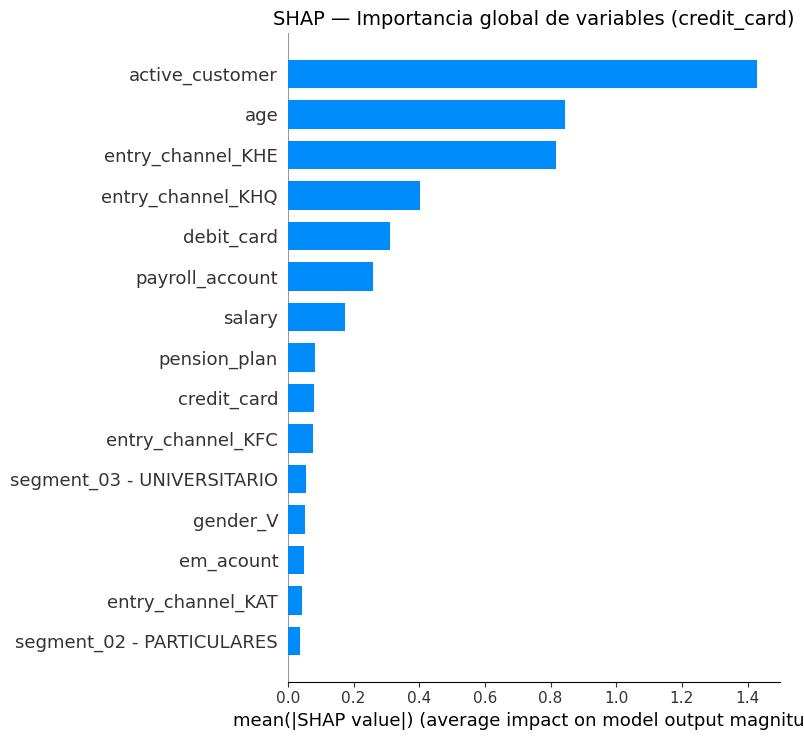

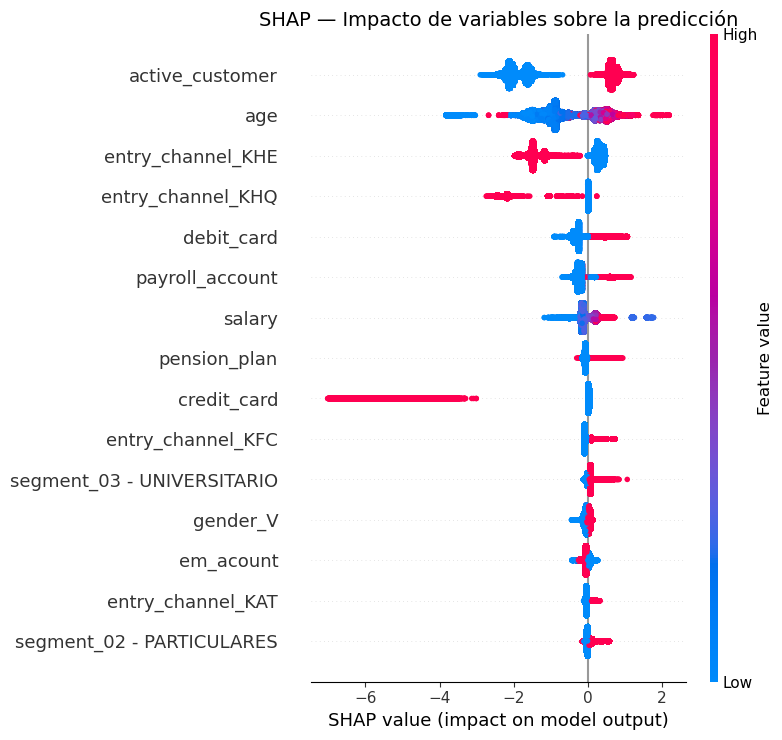

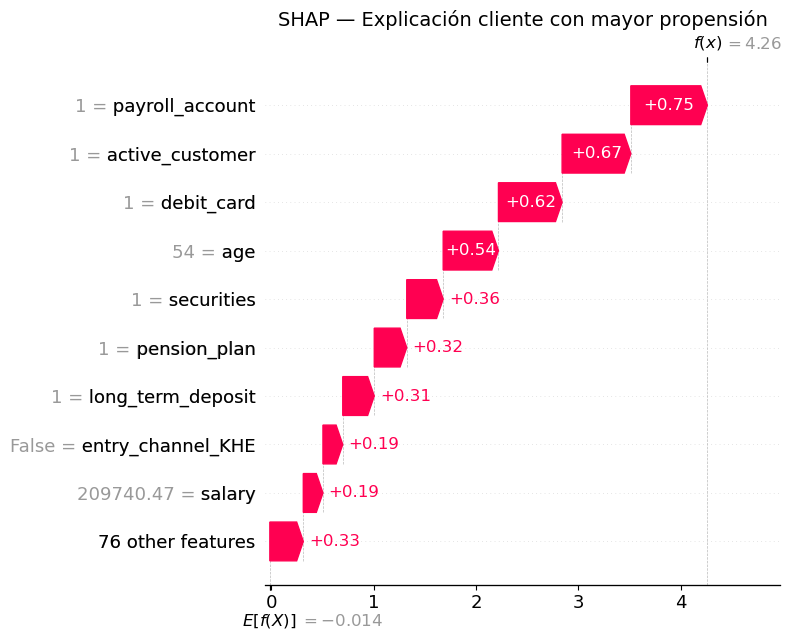

In [61]:
# Usamos el modelo de credit_card por ser el producto recomendado final
modelo_shap = modelos_xgb['credit_card']
X_test_data = df_test[feature_cols].fillna(0)

# Calcular valores SHAP
explainer = shap.TreeExplainer(modelo_shap)
shap_values = explainer.shap_values(X_test_data)

# ── 1. Gráfico de importancia global (summary plot) ──────────
shap.summary_plot(
    shap_values,
    X_test_data,
    feature_names=feature_cols,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('SHAP — Importancia global de variables (credit_card)', fontsize=14)
plt.tight_layout()
plt.show()

# ── 2. Beeswarm plot — impacto y dirección de cada variable ──
shap.summary_plot(
    shap_values,
    X_test_data,
    feature_names=feature_cols,
    max_display=15,
    show=False
)
plt.title('SHAP — Impacto de variables sobre la predicción', fontsize=14)
plt.tight_layout()
plt.show()

# ── 3. Explicación de un cliente concreto (waterfall plot) ───
# Explicamos el cliente con mayor probabilidad de contratar
idx_mejor_cliente = shap_values.sum(axis=1).argmax()

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx_mejor_cliente],
        base_values=explainer.expected_value,
        data=X_test_data.iloc[idx_mejor_cliente],
        feature_names=feature_cols
    ),
    show=False
)
plt.title('SHAP — Explicación cliente con mayor propensión', fontsize=14)
plt.tight_layout()
plt.show()

# 7. Tabla comparativa de resultados

## 1. Comparativa AUC Test

In [ ]:
# Tabla ya calculada en Sección 6 — referencia consolidada
print("COMPARATIVA FINAL — AUC Test:")
print(df_comparativa_final)

print("\nMejor modelo por producto:")
for producto in margenes.keys():
    if not all(producto in d for d in [resultados_eval, resultados_rf, resultados_xgb]):
        continue
    scores = {
        'Decision Tree': resultados_eval[producto]['auc_test'],
        'Random Forest': resultados_rf[producto]['auc_test'],
        'XGBoost':       resultados_xgb[producto]['auc_test']
    }
    mejor = max(scores, key=scores.get)
    print(f"  {producto:<25} → {mejor} (AUC={scores[mejor]:.3f})")

**Conclusión**: 

Usaremos **XGBoost** para el scoring final ya que obtiene el mejor AUC en todos los productos. La pérdida de interpretabilidad respecto al árbol de decisión se compensa con la mejora en rendimiento.

## 2. Comparativa entre los tres modelos

In [63]:
# Comparativa DT vs RF vs XGBoost
# el criterio de selección es AUC, no ROI puntual

roi_dt  = top_10000_dt['valor_esperado_max'].sum()
roi_rf  = top_10000_rf['valor_esperado_max_rf'].sum()
roi_xgb = top_10000_xgb['valor_esperado_max_xgb'].sum()

n_candidatos_dt  = len(top_10000_dt)
n_candidatos_rf  = len(top_10000_rf)
n_candidatos_xgb = len(top_10000_xgb)

auc_medio_dt  = round(sum(v['auc_test'] for v in resultados_eval.values()) / len(resultados_eval), 3)
auc_medio_rf  = round(sum(v['auc_test'] for v in resultados_rf.values())   / len(resultados_rf),   3)
auc_medio_xgb = round(sum(v['auc_test'] for v in resultados_xgb.values()) / len(resultados_xgb), 3)

fig = go.Figure(data=[go.Table(
    header=dict(
        values=[
            '<b>Métrica</b>',
            '<b>Decision Tree</b>',
            '<b>Random Forest</b>',
            '<b>XGBoost</b>'
        ],
        fill_color='#C44E52',
        font=dict(color='white', size=13),
        align='center',
        height=35
    ),
    cells=dict(
        values=[
            ['ROI estimado', 'Clientes candidatos', 'AUC medio (Test)', 'Criterio de selección'],
            [f'{roi_dt:,.0f}€',  f'{n_candidatos_dt:,}',  str(auc_medio_dt),  '—'],
            [f'{roi_rf:,.0f}€',  f'{n_candidatos_rf:,}',  str(auc_medio_rf),  '—'],
            [f'{roi_xgb:,.0f}€', f'{n_candidatos_xgb:,}', str(auc_medio_xgb), '✅ Mejor AUC'],
        ],
        fill_color=[
            ['#f5f5f5', '#f5f5f5', '#f5f5f5', '#f5f5f5'],
            ['#ffffff', '#ffffff', '#ffffff', '#ffffff'],
            ['#ddfee9', '#ddfee9', '#ddfee9', '#ddfee9'],
            ['#eaf4fb', '#eaf4fb', '#eaf4fb', '#eaf4fb'],
        ],
        font=dict(size=12),
        align='center',
        height=30
    )
)])

fig.update_layout(
    title=dict(
        text='Comparativa Decision Tree vs Random Forest vs XGBoost — Scoring Final',
        font=dict(size=16),
        x=0.5
    ),
    width=900,
    height=270,
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.show()

## 3. Propensión media orgánica y ROI por modelo

**Nota importante sobre la métrica**: La probabilidad que devuelve el modelo es la **propensión orgánica** — la probabilidad de que el cliente contrate el producto por su propio comportamiento histórico, no como respuesta directa a un email de campaña.

Esta propensión orgánica es distinta a la tasa de conversión real de la campaña, que en campañas de email marketing de productos financieros suele estar entre el **2% y el 5%**. No disponemos de datos históricos de campañas anteriores para calibrar esta diferencia.

La métrica que calculamos aquí sirve para **comparar modelos entre sí** y para **seleccionar los 10.000 clientes más propensos**, no para proyectar contratos reales.

In [64]:
# Propensión media orgánica por modelo
# P(contratación) = valor_esperado_max / margen(producto recomendado)
# Se divide por el margen del producto recomendado específico de cada cliente

# Decision Tree
probas_dt = top_10000_dt.apply(
    lambda row: row['valor_esperado_max'] / margenes[row['producto_recomendado']], axis=1
)
tasa_dt = probas_dt.mean()
roi_dt  = top_10000_dt['valor_esperado_max'].sum()

# Random Forest
probas_rf = top_10000_rf.apply(
    lambda row: row['valor_esperado_max_rf'] / margenes[row['producto_recomendado_rf']], axis=1
)
tasa_rf = probas_rf.mean()
roi_rf  = top_10000_rf['valor_esperado_max_rf'].sum()

# XGBoost
probas_xgb = top_10000_xgb.apply(
    lambda row: row['valor_esperado_max_xgb'] / margenes[row['producto_recomendado_xgb']], axis=1
)
tasa_xgb = probas_xgb.mean()
roi_xgb  = top_10000_xgb['valor_esperado_max_xgb'].sum()

# Tabla comparativa final con Plotly
fig = go.Figure(data=[go.Table(
    header=dict(
        values=[
            '<b>Métrica</b>',
            '<b>Decision Tree</b>',
            '<b>Random Forest</b>',
            '<b>XGBoost</b>'
        ],
        fill_color='#2C3E50',
        font=dict(color='white', size=13),
        align='center',
        height=35
    ),
    cells=dict(
        values=[
            ['Propensión orgánica media', 'ROI estimado campaña'],
            [f'{tasa_dt:.2%}',  f'{roi_dt:,.0f}€'],
            [f'{tasa_rf:.2%}',  f'{roi_rf:,.0f}€'],
            [f'{tasa_xgb:.2%}', f'{roi_xgb:,.0f}€'],
        ],
        fill_color=['#f5f5f5', '#ffffff', '#ffffff', '#eaf4fb'],
        font=dict(size=12),
        align='center',
        height=30
    )
)])

fig.update_layout(
    title=dict(
        text='Comparativa final — Propensión orgánica media y ROI estimado por modelo',
        font=dict(size=15),
        x=0.5
    ),
    width=900,
    height=220,
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.show()

print(f"\n📊 Resumen (propensión orgánica — ver nota sobre tasa de conversión real):")
print(f"  Decision Tree  → Propensión: {tasa_dt:.2%} | ROI: {roi_dt:,.0f}€")
print(f"  Random Forest  → Propensión: {tasa_rf:.2%} | ROI: {roi_rf:,.0f}€")
print(f"  XGBoost        → Propensión: {tasa_xgb:.2%} | ROI: {roi_xgb:,.0f}€")


📊 Resumen (propensión orgánica — ver nota sobre tasa de conversión real):
  Decision Tree  → Propensión: 92.71% | ROI: 556,262€
  Random Forest  → Propensión: 89.66% | ROI: 537,956€
  XGBoost        → Propensión: 92.08% | ROI: 552,455€


**Conclusión**

El modelo seleccionado para la campaña es **XGBoost**, que obtiene el **mejor AUC en todos los productos** (0.917–0.960), lo que indica mayor capacidad de discriminación entre clientes que contratan y los que no. Aunque el ROI estimado varía ligeramente entre modelos, el criterio de selección principal es la calidad predictiva (AUC), no el ROI puntual sobre los datos de scoring.

Los 10.000 clientes seleccionados tienen como producto recomendado la **credit_card**, 
lo cual es coherente: para estos clientes, credit_card tiene la mayor probabilidad de 
contratación y, dado que su margen (60€) es también el más alto del catálogo modelado, 
domina tanto en criterio probabilístico como en valor esperado. Este resultado reproduce 
la señal real del negocio.

La **personalización** de la campaña se realiza a nivel de mensaje (creatividad), adaptando el tono del email al perfil sociodemográfico de cada segmento, aunque el producto recomendado sea el mismo.

**Limitación**: La propensión orgánica media (~92%) refleja la probabilidad histórica de contratación, no la tasa de conversión real del email. Las campañas de email en banca suelen tener tasas de conversión reales del 2–5%.

# 8. Gráficos interesantes

## 1. Comparativa AUC Test por modelo y producto. 

In [65]:
productos = [p for p in margenes.keys() if p in resultados_eval]
auc_dt  = [round(resultados_eval[p]['auc_test'], 3) for p in productos]
auc_rf  = [round(resultados_rf[p]['auc_test'], 3)   for p in productos]
auc_xgb = [round(resultados_xgb[p]['auc_test'], 3)  for p in productos]

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Decision Tree',
    x=productos,
    y=auc_dt,
    marker_color='#4C72B0',
    text=auc_dt,
    textposition='outside'
))

fig.add_trace(go.Bar(
    name='Random Forest',
    x=productos,
    y=auc_rf,
    marker_color='#55A868',
    text=auc_rf,
    textposition='outside'
))

fig.add_trace(go.Bar(
    name='XGBoost',
    x=productos,
    y=auc_xgb,
    marker_color='#C44E52',
    text=auc_xgb,
    textposition='outside'
))

fig.update_layout(
    title=dict(
        text='Comparativa AUC Test por Modelo y Producto',
        font=dict(size=18),
        x=0.5
    ),
    xaxis_title='Producto',
    yaxis_title='AUC Test',
    yaxis=dict(range=[0.85, 0.97]),
    barmode='group',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1
    ),
    template='plotly_white',
    width=1000,
    height=550
)

fig.show()

## 2. Curvas ROC por producto y modelo

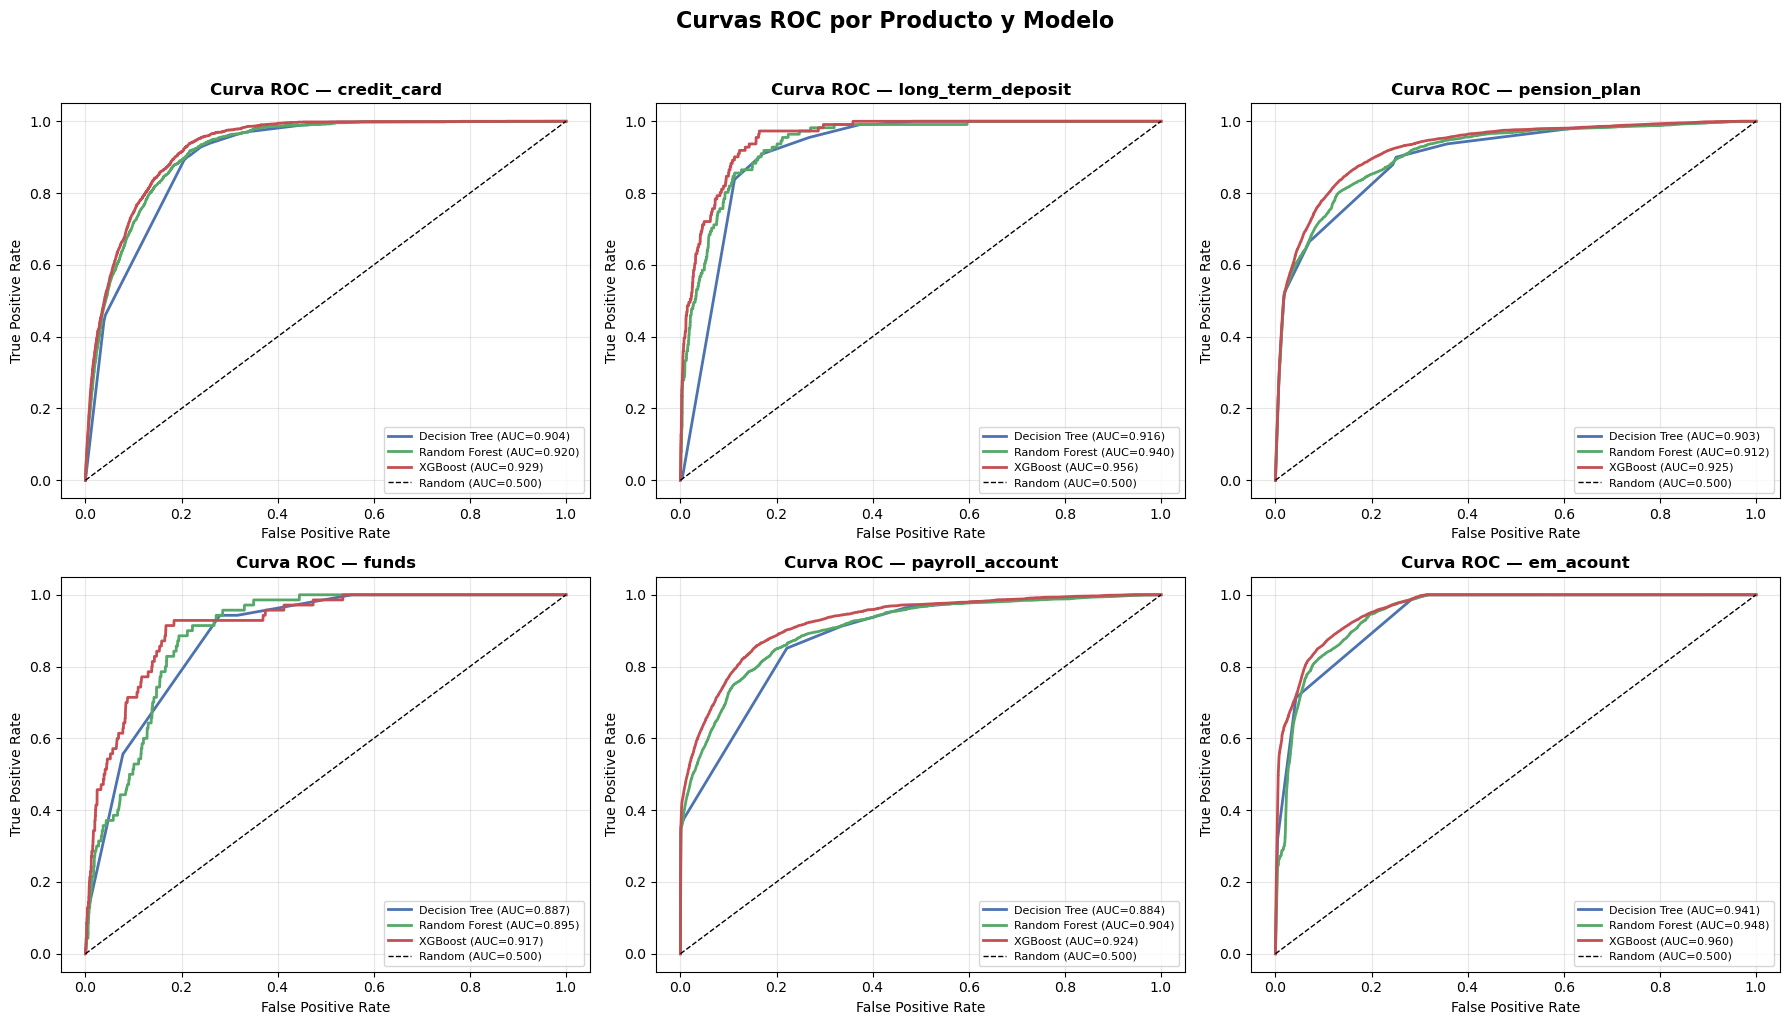

In [66]:
# ── 2. Curva ROC por modelo para credit_card ─────────────────
X_test_data = df_test[feature_cols].fillna(0)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, producto in enumerate(productos):
    ax = axes[idx]
    y_test_data = df_test[f'target_{producto}']

    for nombre, modelo, color in [
        ('Decision Tree', modelos[producto],     '#4C72B0'),
        ('Random Forest', modelos_rf[producto],  '#55A868'),
        ('XGBoost',       modelos_xgb[producto], '#C44E52')
    ]:
        fpr, tpr, _ = roc_curve(y_test_data, modelo.predict_proba(X_test_data)[:,1])
        auc = roc_auc_score(y_test_data, modelo.predict_proba(X_test_data)[:,1])
        ax.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})', color=color, linewidth=2)

    ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC=0.500)')
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(f'Curva ROC — {producto}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Curvas ROC por Producto y Modelo', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Conclusiones**

- Credit_card, long_term_deposit, pension_plan, em_acount: Las tres curvas están muy juntas y alejadas de la diagonal, modelos muy sólidos.
- Funds: La curva de Decision Tree tiene forma escalonada típica de pocas muestras positivas, pero XGBoost y RF se comportan bien.
- Payroll_account: Hay más separación entre modelos, XGBoost gana claramente.

**Conclusiones del punto 8**:

- **Barras comparativo**: AUC Test de los 3 modelos por producto de un vistazo — XGBoost supera a DT y RF en todos los productos.
- **Curvas ROC**: Muestran el rendimiento detallado de los 3 modelos para cada producto. Credit_card, long_term_deposit, pension_plan y em_acount son los productos con curvas más sólidas.

# 9. Personalización de los 10.000 + creatividades

> **Nota metodológica:** Esta sección realiza una personalización **preliminar** basada
> en variables numéricas y demográficas (age, salary, gender). La **Tarea 4 (Notebook 06)**
> sustituye y mejora esta segmentación, incorporando las variables ordinales
> correctamente codificadas (age_group, salary_group) y enriqueciendo el profiling
> posterior con la segmentación comportamental de la Tarea 2.
> El fichero `recomendacion_10000_clientes.csv` generado aquí es el input de Notebook 06.

In [67]:
# Features sociodemográficas para el clustering
# Usamos solo las variables de perfil del cliente, no los productos
features_clustering = ['age', 'salary']

# Añadir género si está disponible como dummy
# Excluir gender_UNKNOWN — varianza casi nula (prevalencia ~0%) — no aporta poder discriminante
gender_cols = [c for c in top_10000_xgb.columns
               if c.startswith('gender_') and c != 'gender_UNKNOWN']
features_clustering += gender_cols

print(f"Features para clustering: {features_clustering}")

# Preparar datos
X_clust = top_10000_xgb[features_clustering].fillna(0)

# Escalar — muy importante para K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

# ── Método del codo para validar que 5 es un buen número ─────
inertias = []
silhouettes = []
rango_k = range(2, 10)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

# Gráfico del codo
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=list(rango_k), y=inertias,
    mode='lines+markers',
    name='Inercia',
    line=dict(color='#C44E52', width=2),
    marker=dict(size=8)
))
fig.update_layout(
    title=dict(text='Método del Codo — Selección de K', x=0.5, font=dict(size=16)),
    xaxis_title='Número de clusters (K)',
    yaxis_title='Inercia',
    template='plotly_white',
    width=800, height=400
)
fig.show()

# Gráfico silhouette
fig2 = go.Figure()
fig2.add_trace(go.Scatter(
    x=list(rango_k), y=silhouettes,
    mode='lines+markers',
    name='Silhouette',
    line=dict(color='#55A868', width=2),
    marker=dict(size=8)
))
fig2.update_layout(
    title=dict(text='Silhouette Score — Selección de K', x=0.5, font=dict(size=16)),
    xaxis_title='Número de clusters (K)',
    yaxis_title='Silhouette Score',
    template='plotly_white',
    width=800, height=400
)
fig2.show()

print("\nInercia y Silhouette por K:")
for k, ine, sil in zip(rango_k, inertias, silhouettes):
    print(f"  K={k}: Inercia={ine:,.0f} | Silhouette={sil:.3f}")

Features para clustering: ['age', 'salary', 'gender_V']



Inercia y Silhouette por K:
  K=2: Inercia=19,990 | Silhouette=0.436
  K=3: Inercia=14,887 | Silhouette=0.463
  K=4: Inercia=10,379 | Silhouette=0.475
  K=5: Inercia=8,203 | Silhouette=0.471
  K=6: Inercia=7,106 | Silhouette=0.477
  K=7: Inercia=6,268 | Silhouette=0.421
  K=8: Inercia=5,624 | Silhouette=0.430
  K=9: Inercia=5,064 | Silhouette=0.423


**Conclusiones del análisis del codo**

- Inercia: baja consistentemente; el "codo" más claro está en K=5 donde la bajada empieza a suavizarse.
- Silhouette: el valor más alto es en K=6 (0.477). Cabe destacar que **K=4 (0.475) supera ligeramente a K=5 (0.471)** — es decir, añadir un 5º cluster tiene un coste estadístico pequeño pero medible.
- Esta pequeña penalización estadística de K=5 frente a K=4 queda totalmente justificada por el **requisito de negocio**: el proyecto requiere 5 creatividades diferenciadas. K=4 generaría mensajes insuficientemente granulares para cubrir los perfiles identificados (jóvenes vs maduros × masculino vs femenino × alto salario).
- La diferencia entre K=5 y el óptimo K=6 es mínima (0.471 vs 0.477), lo que confirma que **K=5 está perfectamente justificado**.

In [68]:
# KMeans con K=5 sobre los 10.000 clientes seleccionados
K_CAMP = 5

km_final = KMeans(n_clusters=K_CAMP, random_state=RANDOM_STATE, n_init=10)
km_final.fit(X_scaled)

top_10000_xgb = top_10000_xgb.copy()
top_10000_xgb['cluster_raw'] = km_final.labels_

# Ordenar clusters de forma estable según el salario medio
# (cluster con menor salario = cluster 0, mayor salario = cluster 4)
cluster_order = (
    top_10000_xgb.groupby('cluster_raw')['salary']
    .mean()
    .sort_values()
    .reset_index()
)
cluster_order['cluster'] = range(len(cluster_order))
mapping = dict(zip(cluster_order['cluster_raw'], cluster_order['cluster']))
top_10000_xgb['cluster'] = top_10000_xgb['cluster_raw'].map(mapping)

print("Orden estable de clusters (salario medio):")
print(cluster_order)

# Perfil medio de cada clúster
perfil_clusters = top_10000_xgb.groupby('cluster')[features_clustering + ['producto_recomendado_xgb']].agg( 
    {**{f: 'mean' for f in features_clustering},
     'producto_recomendado_xgb': lambda x: x.value_counts().idxmax()}
).round(2)
perfil_clusters.columns = list(features_clustering) + ['producto_top']
perfil_clusters['n_clientes'] = top_10000_xgb.groupby('cluster').size()

print(f"KMeans K={K_CAMP} — Distribución de clientes por clúster:")
print(perfil_clusters)
print(f"\nTotal clientes: {top_10000_xgb['cluster'].notna().sum():,}")

Orden estable de clusters (salario medio):
   cluster_raw         salary  cluster
0            0   95406.651292        0
1            2   99809.420570        1
2            1  106391.601728        2
3            4  115443.941455        3
4            3  449446.217732        4
KMeans K=5 — Distribución de clientes por clúster:
           age     salary  gender_V producto_top  n_clientes
cluster                                                     
0        34.32   95406.65      1.00  credit_card        3762
1        34.51   99809.42      0.00  credit_card        2701
2        52.78  106391.60      0.00  credit_card        1244
3        53.43  115443.94      1.00  credit_card        1980
4        40.08  449446.22      0.52  credit_card         313

Total clientes: 10,000


In [69]:
# Creatividades por clúster — todos recomiendan credit_card,
# pero con un mensaje adaptado al perfil sociodemográfico de cada segmento.
#
# Perfil real de cada clúster (verificado contra output de la celda anterior):
#   Cluster 0: age ~34a, gender_V=1.00 (hombres),  salary ~95k  → Hombres jóvenes
#   Cluster 1: age ~35a, gender_V=0.00 (mujeres),  salary ~99k  → Mujeres jóvenes
#   Cluster 2: age ~53a, gender_V=0.00 (mujeres),  salary ~106k → Mujeres maduras
#   Cluster 3: age ~53a, gender_V=1.00 (hombres),  salary ~115k → Hombres maduros
#   Cluster 4: age ~40a, gender_V=0.52 (mixto),    salary ~448k → Ultra-alto salario

creatividades = {
    0: "Saca más partido a cada compra — acumula puntos y cashback con tu tarjeta easyMoney",
    1: "Controla tus gastos y gana cashback en cada compra del día a día",
    2: "Paga con total seguridad y sin comisiones — la tarjeta pensada para tu tranquilidad",
    3: "Accede a beneficios premium, seguros incluidos y ventajas exclusivas con tu tarjeta",
    4: "Viaja y compra en cualquier parte del mundo con la cobertura que mereces"
}

top_10000_xgb['creatividad'] = top_10000_xgb['cluster'].map(creatividades)

print("Creatividades asignadas por clúster (producto: credit_card en todos):")
for cluster_id, msg in creatividades.items():
    n = (top_10000_xgb['cluster'] == cluster_id).sum()
    perfil = {
        0: "Hombres jóvenes ~34a",
        1: "Mujeres jóvenes ~35a",
        2: "Mujeres maduras ~53a",
        3: "Hombres maduros ~53a",
        4: "Alto salario mixto ~40a"
    }[cluster_id]
    print(f"  Clúster {cluster_id} ({n:,} clientes | {perfil}): {msg}")

# Exportar CSV final con clúster y creatividad
output_cols = ['pk_cid', 'producto_recomendado_xgb', 'cluster', 'creatividad']
df_export = top_10000_xgb[output_cols].rename(columns={
    'pk_cid': 'id_user',
    'producto_recomendado_xgb': 'recommended_product',
    'creatividad': 'nombre_creatividad'
})
df_export.to_csv('recomendacion_10000_clientes.csv', index=False)
print(f"\n✅ recomendacion_10000_clientes.csv actualizado con clúster y creatividad")
print(df_export.head(5))

Creatividades asignadas por clúster (producto: credit_card en todos):
  Clúster 0 (3,762 clientes | Hombres jóvenes ~34a): Saca más partido a cada compra — acumula puntos y cashback con tu tarjeta easyMoney
  Clúster 1 (2,701 clientes | Mujeres jóvenes ~35a): Controla tus gastos y gana cashback en cada compra del día a día
  Clúster 2 (1,244 clientes | Mujeres maduras ~53a): Paga con total seguridad y sin comisiones — la tarjeta pensada para tu tranquilidad
  Clúster 3 (1,980 clientes | Hombres maduros ~53a): Accede a beneficios premium, seguros incluidos y ventajas exclusivas con tu tarjeta
  Clúster 4 (313 clientes | Alto salario mixto ~40a): Viaja y compra en cualquier parte del mundo con la cobertura que mereces

✅ recomendacion_10000_clientes.csv actualizado con clúster y creatividad
         id_user recommended_product  cluster  \
1512554  1114367         credit_card        3   
919361   1070525         credit_card        3   
5301071  1437442         credit_card        3   
1627